# Train toxic/safe model — language-aware optimized version

Notebook này tối ưu riêng cho **tiếng Việt** và **tiếng Anh**, thay vì dùng một pipeline xử lý văn bản chung cho cả hai.

Các điểm nâng cấp chính:

- Tiếng Việt: chuẩn hóa teencode, giữ dấu tiếng Việt, thêm nhánh không dấu, word segmentation bằng `pyvi` nếu có, char n-gram để bắt biến thể né lọc, badword lexicon feature.
- Tiếng Anh: expand contractions, normalize leetspeak/obfuscation nhẹ, word + char n-gram riêng, optional English badword lexicon.
- Mỗi ngôn ngữ có **search-space riêng** cho TF-IDF và classifier.
- Model nhận **raw text** trực tiếp khi inference, không còn lỗi train một kiểu predict một kiểu.
- Có validation riêng để tune threshold, test riêng để đánh giá cuối.
- Có error analysis: xuất false positive / false negative để bổ sung dữ liệu khó.

> Nếu bạn chỉ deploy tiếng Việt, có thể chạy riêng các cell tiếng Việt. Nếu app có cả tiếng Anh, chạy thêm phần tiếng Anh.

## 0. Cài thư viện

Chạy cell dưới nếu môi trường chưa có thư viện. Nếu đã có thì bỏ qua.

In [ ]:
# %pip install -q pandas numpy scipy scikit-learn joblib matplotlib pyvi
# Optional nếu muốn fine-tune Transformer/PhoBERT/XLM-R:
# %pip install -q torch transformers datasets evaluate accelerate

## 1. Config

Sửa đường dẫn file CSV cho đúng với thư mục của bạn. Notebook tự nhận các cột phổ biến:

- Vietnamese: `free_text` hoặc `text`; label: `label_id`, `label`, `toxic`.
- English: `comment_text` hoặc `text`; label: `toxic`, `label`.
- Vietnamese label `0/1/2` sẽ map thành binary: `0=safe`, `1/2=toxic`.

In [1]:
from pathlib import Path

RANDOM_STATE = 42

# Data paths
TRAIN_VI_PATH = Path("train_vi.csv")
TRAIN_EN_PATH = Path("train_en.csv")
TEST_VI_PATH = Path("test_vi.csv")   # optional external test
TEST_EN_PATH = Path("test_en.csv")   # optional external test

# Optional lexicons. Hỗ trợ .json list/dict hoặc .txt mỗi dòng một từ/cụm từ.
VI_BADWORDS_PATH = Path("vi_badwords.json")
EN_BADWORDS_PATH = Path("en_badwords.json")

# Output paths
OUTPUT_DIR = Path("outputs_lang_aware")
MODEL_DIR = OUTPUT_DIR / "models"
REPORT_DIR = OUTPUT_DIR / "reports"
ERROR_DIR = OUTPUT_DIR / "errors"
for p in [OUTPUT_DIR, MODEL_DIR, REPORT_DIR, ERROR_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Search budget. Tăng lên 40-80 nếu máy khỏe và dữ liệu lớn.
N_ITER_SEARCH_VI = 30
N_ITER_SEARCH_EN = 30
CV_FOLDS = 3

# Threshold target
# - f1_macro: cân bằng safe/toxic
# - f1_toxic: ưu tiên class toxic
# - recall_toxic: ưu tiên bắt toxic, dễ tăng false positive hơn
THRESHOLD_METRIC_VI = "f1_toxic"
THRESHOLD_METRIC_EN = "f1_toxic"

# Moderation app thường muốn recall toxic cao. Có thể đặt 0.85/0.9 nếu cần.
MIN_RECALL_TOXIC_VI = None
MIN_PRECISION_TOXIC_VI = None
MIN_RECALL_TOXIC_EN = None
MIN_PRECISION_TOXIC_EN = None

print("✅ Config ready")

✅ Config ready


## 2. Utility module

Cell này tạo file `toxic_text_lang_utils.py`. Khi deploy API, bạn cần copy cả file `.pkl` model và file utils này để `joblib.load()` hoạt động ổn định.

In [2]:
%%writefile toxic_text_lang_utils.py
from __future__ import annotations

import html
import json
import re
import unicodedata
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

import joblib
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import MaxAbsScaler

try:
    from pyvi import ViTokenizer
except Exception:
    ViTokenizer = None

LABEL_MAP_DEFAULT = {0: 0, 1: 1, 2: 1, "0": 0, "1": 1, "2": 1}

# Không nên xóa stopwords cho bài toán toxic vì từ phủ định/ngữ cảnh có thể quan trọng.
EN_CONTRACTIONS = {
    "can't": "can not",
    "cannot": "can not",
    "won't": "will not",
    "n't": " not",
    "i'm": "i am",
    "you're": "you are",
    "he's": "he is",
    "she's": "she is",
    "it's": "it is",
    "we're": "we are",
    "they're": "they are",
    "i've": "i have",
    "you've": "you have",
    "we've": "we have",
    "they've": "they have",
    "i'll": "i will",
    "you'll": "you will",
    "we'll": "we will",
    "they'll": "they will",
    "i'd": "i would",
    "you'd": "you would",
    "we'd": "we would",
    "they'd": "they would",
}

VI_TEENCODE_MAP = {
    "ko": "không", "k": "không", "khong": "không", "khum": "không", "hok": "không", "hong": "không",
    "dc": "được", "đc": "được", "duoc": "được",
    "j": "gì", "gi": "gì",
    "mik": "mình", "mk": "mình", "m": "mày", "t": "tao",
    "bn": "bạn", "b": "bạn", "ny": "người_yêu",
    "vl": "__vi_toxic_slang__", "vcl": "__vi_toxic_slang__", "vkl": "__vi_toxic_slang__",
    "dm": "__vi_toxic_slang__", "đm": "__vi_toxic_slang__", "dmm": "__vi_toxic_slang__", "đmm": "__vi_toxic_slang__",
    "cc": "__vi_toxic_slang__", "cl": "__vi_toxic_slang__",
}

LEET_TABLE = str.maketrans({"0": "o", "1": "i", "3": "e", "4": "a", "5": "s", "7": "t", "@": "a", "$": "s"})


def strip_vietnamese_accents(text: str) -> str:
    text = unicodedata.normalize("NFD", text)
    text = "".join(ch for ch in text if unicodedata.category(ch) != "Mn")
    text = text.replace("đ", "d").replace("Đ", "D")
    return unicodedata.normalize("NFC", text)


def reduce_flooding(text: str, keep: int = 2) -> str:
    # nguoooo -> nguoo; fuuuu -> fuu. Giữ 2 ký tự để model vẫn học được sắc thái nhấn mạnh.
    return re.sub(r"([A-Za-zÀ-ỹ])\1{" + str(keep) + r",}", lambda m: m.group(1) * keep, text)


def normalize_noise(text: Any) -> str:
    if pd.isna(text):
        return ""
    text = html.unescape(str(text))
    text = unicodedata.normalize("NFC", text)
    text = text.replace("\u200b", " ").replace("\ufeff", " ")
    text = re.sub(r"https?://\S+|www\.\S+", " URL ", text)
    text = re.sub(r"[\w\.-]+@[\w\.-]+", " EMAIL ", text)
    text = re.sub(r"@\w+", " USER ", text)
    text = re.sub(r"#(\w+)", r" \1 ", text)
    return text


def normalize_vietnamese(
    text: Any,
    tokenize: bool = True,
    remove_accents: bool = False,
    keep_toxic_placeholders: bool = True,
) -> str:
    text = normalize_noise(text).lower()
    text = reduce_flooding(text, keep=2)

    # Tách những trường hợp viết kiểu d.m, đ*m, d-m về token gần hơn.
    text = re.sub(r"[dđ][\W_]*[m]", " dm ", text)

    # Giữ ! ? vì hữu ích trong toxic; phần còn lại đưa về space.
    text = re.sub(r"[^0-9a-zA-ZÀ-ỹ_!?\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = []
    for tok in text.split():
        mapped = VI_TEENCODE_MAP.get(tok, tok)
        if mapped.startswith("__vi_toxic_slang__") and not keep_toxic_placeholders:
            mapped = tok
        tokens.append(mapped)
    text = " ".join(tokens)

    if remove_accents:
        text = strip_vietnamese_accents(text)

    if tokenize and ViTokenizer is not None and text:
        text = ViTokenizer.tokenize(text)

    text = re.sub(r"\s+", " ", text).strip()
    return text


def normalize_english(text: Any, deobfuscate: bool = True) -> str:
    text = normalize_noise(text).lower()
    text = reduce_flooding(text, keep=2)

    # Expand contractions trước khi remove punctuation.
    for k, v in EN_CONTRACTIONS.items():
        text = text.replace(k, v)

    # Chuẩn hóa một số kiểu né lọc: f.u.c.k -> f u c k; f*ck giữ char ngram bắt được.
    text = re.sub(r"([a-zA-Z])[\.\-_\*]+(?=[a-zA-Z])", r"\1", text)
    if deobfuscate:
        # Leetspeak nhẹ, không thay mọi số trong toàn câu bằng chữ nếu token có cả chữ và số.
        parts = []
        for tok in text.split():
            if re.search(r"[a-zA-Z]", tok) and re.search(r"[013457@$]", tok):
                parts.append(tok.translate(LEET_TABLE))
            else:
                parts.append(tok)
        text = " ".join(parts)

    text = re.sub(r"[^0-9a-zA-Z_!?\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def normalize_for_language(text: Any, language: str, mode: str = "word") -> str:
    language = language.lower()
    if language.startswith("vi"):
        if mode == "vi_accentless":
            return normalize_vietnamese(text, tokenize=False, remove_accents=True)
        if mode == "vi_syllable":
            return normalize_vietnamese(text, tokenize=False, remove_accents=False)
        return normalize_vietnamese(text, tokenize=True, remove_accents=False)
    if language.startswith("en"):
        return normalize_english(text, deobfuscate=True)
    return normalize_english(text, deobfuscate=True)


def load_lexicon(file_path: str | Path | None, language: str = "vi") -> set[str]:
    if not file_path:
        return set()
    file_path = Path(file_path)
    if not file_path.exists():
        print(f"⚠️ Không tìm thấy lexicon: {file_path}. Bỏ qua lexicon feature.")
        return set()

    try:
        if file_path.suffix.lower() == ".json":
            with file_path.open("r", encoding="utf-8") as f:
                data = json.load(f)
            if isinstance(data, dict):
                values = list(data.keys()) + [str(x) for v in data.values() if isinstance(v, list) for x in v]
            elif isinstance(data, list):
                values = data
            else:
                values = []
        else:
            values = file_path.read_text(encoding="utf-8").splitlines()

        lex = set()
        for v in values:
            v = str(v).strip()
            if not v:
                continue
            lex.add(normalize_for_language(v, language=language, mode="word" if language.startswith("en") else "vi_syllable"))
            if language.startswith("vi"):
                lex.add(normalize_for_language(v, language=language, mode="vi_accentless"))
        lex = {x for x in lex if x}
        print(f"✅ Loaded {len(lex)} lexicon terms from {file_path}")
        return lex
    except Exception as e:
        print(f"⚠️ Lỗi đọc lexicon {file_path}: {e}. Bỏ qua.")
        return set()


class LanguagePreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self, language: str = "vi", mode: str = "word"):
        self.language = language
        self.mode = mode

    def fit(self, X: Sequence[Any], y: Optional[Sequence[int]] = None):
        return self

    def transform(self, X: Sequence[Any]) -> List[str]:
        return [normalize_for_language(x, language=self.language, mode=self.mode) for x in X]


class ToxicTextStats(BaseEstimator, TransformerMixin):
    def __init__(self, language: str = "vi", lexicon: Optional[set[str]] = None):
        self.language = language
        self.lexicon = lexicon or set()

    def fit(self, X: Sequence[Any], y: Optional[Sequence[int]] = None):
        return self

    def transform(self, X: Sequence[Any]) -> csr_matrix:
        rows = []
        for raw in X:
            raw_text = "" if pd.isna(raw) else str(raw)
            norm_word = normalize_for_language(raw_text, self.language, mode="word")
            norm_plain = normalize_for_language(raw_text, self.language, mode="vi_syllable" if self.language.startswith("vi") else "word")
            norm_accentless = strip_vietnamese_accents(norm_plain) if self.language.startswith("vi") else norm_plain
            tokens = norm_word.split()
            plain_tokens = norm_plain.split()

            char_len = len(raw_text)
            token_count = len(tokens)
            unique_ratio = len(set(tokens)) / max(token_count, 1)
            exclam_count = raw_text.count("!")
            question_count = raw_text.count("?")
            digit_count = sum(ch.isdigit() for ch in raw_text)
            upper_chars = sum(ch.isupper() for ch in raw_text)
            alpha_chars = sum(ch.isalpha() for ch in raw_text)
            uppercase_ratio = upper_chars / max(alpha_chars, 1)
            repeated_punct = len(re.findall(r"([!?])\1+", raw_text))
            repeated_chars = len(re.findall(r"([A-Za-zÀ-ỹ])\1{2,}", raw_text))
            url_count = len(re.findall(r"https?://|www\.", raw_text.lower()))
            user_mention_count = len(re.findall(r"@\w+", raw_text))

            # Lexicon hit: token-level + substring-level + accentless branch for Vietnamese.
            token_set = set(tokens) | set(plain_tokens)
            lex_token_hits = sum(1 for w in self.lexicon if w in token_set)
            lex_substring_hits = 0
            if self.lexicon:
                joined = " " + norm_plain + " "
                joined_acc = " " + norm_accentless + " "
                for w in self.lexicon:
                    if len(w) >= 3 and ((" " + w + " ") in joined or w in joined_acc):
                        lex_substring_hits += 1

            if self.language.startswith("vi"):
                slang_hits = sum(1 for t in norm_plain.split() if t == "__vi_toxic_slang__")
                accentless_ratio = sum(1 for ch in raw_text if ch in "ăâđêôơưáàảãạắằẳẵặấầẩẫậéèẻẽẹếềểễệíìỉĩịóòỏõọốồổỗộớờởỡợúùủũụứừửữựýỳỷỹỵ") / max(alpha_chars, 1)
                deobf_hits = slang_hits
            else:
                slang_hits = 0
                accentless_ratio = 0.0
                deobf = normalize_english(raw_text, deobfuscate=True)
                raw_norm = normalize_english(raw_text, deobfuscate=False)
                deobf_hits = int(deobf != raw_norm)

            rows.append([
                np.log1p(char_len),
                np.log1p(token_count),
                unique_ratio,
                np.log1p(exclam_count),
                np.log1p(question_count),
                np.log1p(digit_count),
                uppercase_ratio,
                np.log1p(repeated_punct),
                np.log1p(repeated_chars),
                np.log1p(url_count),
                np.log1p(user_mention_count),
                np.log1p(lex_token_hits),
                np.log1p(lex_substring_hits),
                np.log1p(slang_hits),
                accentless_ratio,
                np.log1p(deobf_hits),
            ])
        return csr_matrix(np.asarray(rows, dtype=np.float32))


def make_language_features(
    language: str,
    lexicon: Optional[set[str]] = None,
    word_max_features: int = 50000,
    char_max_features: int = 50000,
    aux_max_features: int = 25000,
    word_ngram_range: Tuple[int, int] = (1, 3),
    char_ngram_range: Tuple[int, int] = (2, 6),
    min_df: int = 2,
    max_df: float = 0.98,
) -> FeatureUnion:
    language = language.lower()

    word_pipe = Pipeline([
        ("prep", LanguagePreprocessor(language=language, mode="word")),
        ("tfidf", TfidfVectorizer(
            analyzer="word",
            ngram_range=word_ngram_range,
            max_features=word_max_features,
            min_df=min_df,
            max_df=max_df,
            sublinear_tf=True,
            token_pattern=r"(?u)\b\w+\b",
        )),
    ])

    char_pipe = Pipeline([
        ("prep", LanguagePreprocessor(language=language, mode="vi_syllable" if language.startswith("vi") else "word")),
        ("tfidf", TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=char_ngram_range,
            max_features=char_max_features,
            min_df=min_df,
            max_df=max_df,
            sublinear_tf=True,
        )),
    ])

    transformers = [("word", word_pipe), ("char", char_pipe)]

    if language.startswith("vi"):
        # Nhánh syllable giữ cách viết gốc tiếng Việt, giúp bắt câu không tách từ tốt.
        syllable_pipe = Pipeline([
            ("prep", LanguagePreprocessor(language=language, mode="vi_syllable")),
            ("tfidf", TfidfVectorizer(
                analyzer="word",
                ngram_range=(1, 4),
                max_features=aux_max_features,
                min_df=min_df,
                max_df=max_df,
                sublinear_tf=True,
                token_pattern=r"(?u)\b\w+\b",
            )),
        ])
        # Nhánh không dấu giúp bắt dữ liệu người dùng gõ thiếu dấu.
        accentless_char_pipe = Pipeline([
            ("prep", LanguagePreprocessor(language=language, mode="vi_accentless")),
            ("tfidf", TfidfVectorizer(
                analyzer="char_wb",
                ngram_range=(3, 6),
                max_features=aux_max_features,
                min_df=min_df,
                max_df=max_df,
                sublinear_tf=True,
            )),
        ])
        transformers.extend([("syllable", syllable_pipe), ("accentless_char", accentless_char_pipe)])
    else:
        # Nhánh word dài hơn cho tiếng Anh để bắt cụm toxic nhiều từ.
        long_word_pipe = Pipeline([
            ("prep", LanguagePreprocessor(language=language, mode="word")),
            ("tfidf", TfidfVectorizer(
                analyzer="word",
                ngram_range=(2, 4),
                max_features=aux_max_features,
                min_df=min_df,
                max_df=max_df,
                sublinear_tf=True,
                token_pattern=r"(?u)\b\w+\b",
            )),
        ])
        transformers.append(("long_word", long_word_pipe))

    stats_pipe = Pipeline([
        ("stats", ToxicTextStats(language=language, lexicon=lexicon)),
        ("scale", MaxAbsScaler()),
    ])
    transformers.append(("stats", stats_pipe))

    return FeatureUnion(transformer_list=transformers, n_jobs=None)


def read_dataset(
    path: str | Path,
    language: str,
    text_candidates: Sequence[str],
    label_candidates: Sequence[str],
    label_map: Optional[dict] = None,
    sample_n: Optional[int] = None,
    random_state: int = 42,
) -> pd.DataFrame:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Không tìm thấy file: {path}")

    df = pd.read_csv(path)
    text_col = next((c for c in text_candidates if c in df.columns), None)
    label_col = next((c for c in label_candidates if c in df.columns), None)
    if text_col is None:
        raise ValueError(f"Không tìm thấy cột text trong {path}. Columns: {list(df.columns)}")
    if label_col is None:
        raise ValueError(f"Không tìm thấy cột label trong {path}. Columns: {list(df.columns)}")

    out = df[[text_col, label_col]].rename(columns={text_col: "text", label_col: "label"}).copy()
    out["text"] = out["text"].fillna("").astype(str)
    label_map = label_map if label_map is not None else LABEL_MAP_DEFAULT
    out["label"] = out["label"].map(label_map).fillna(out["label"])
    out["label"] = pd.to_numeric(out["label"], errors="coerce")
    out = out.dropna(subset=["label"])
    out["label"] = out["label"].astype(int)
    out = out[out["label"].isin([0, 1])]

    # Dedup theo normalized text để giảm duplicate leakage giữa split.
    dedup_mode = "vi_accentless" if language.startswith("vi") else "word"
    out["_dedup_text"] = out["text"].map(lambda x: normalize_for_language(x, language=language, mode=dedup_mode))
    out = out[out["_dedup_text"].str.len() > 0]
    out = out.drop_duplicates(subset=["_dedup_text", "label"]).drop(columns=["_dedup_text"])

    if sample_n is not None and len(out) > sample_n:
        # Stratified sample gần đúng.
        parts = []
        for label, g in out.groupby("label"):
            n = max(1, int(sample_n * len(g) / len(out)))
            parts.append(g.sample(n=min(n, len(g)), random_state=random_state))
        out = pd.concat(parts).sample(frac=1, random_state=random_state).reset_index(drop=True)

    out["language"] = language
    return out.reset_index(drop=True)


def get_positive_proba(model: Any, X: Sequence[str]) -> np.ndarray:
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X)
        return 1 / (1 + np.exp(-scores))
    raise TypeError("Model không hỗ trợ predict_proba hoặc decision_function")


def find_best_threshold(
    y_true: Sequence[int],
    y_proba: Sequence[float],
    metric: str = "f1_toxic",
    min_precision_toxic: Optional[float] = None,
    min_recall_toxic: Optional[float] = None,
) -> Tuple[float, pd.DataFrame]:
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    rows = []
    for thr in np.round(np.linspace(0.03, 0.97, 189), 3):
        pred = (y_proba >= thr).astype(int)
        precision, recall, f1, support = precision_recall_fscore_support(y_true, pred, labels=[0, 1], zero_division=0)
        rows.append({
            "threshold": float(thr),
            "f1_macro": float(f1_score(y_true, pred, average="macro", zero_division=0)),
            "f1_toxic": float(f1[1]),
            "precision_toxic": float(precision[1]),
            "recall_toxic": float(recall[1]),
            "precision_safe": float(precision[0]),
            "recall_safe": float(recall[0]),
        })
    df = pd.DataFrame(rows)
    filtered = df.copy()
    if min_precision_toxic is not None:
        filtered = filtered[filtered["precision_toxic"] >= min_precision_toxic]
    if min_recall_toxic is not None:
        filtered = filtered[filtered["recall_toxic"] >= min_recall_toxic]
    if filtered.empty:
        filtered = df.copy()
    if metric not in filtered.columns:
        raise ValueError(f"Metric không hợp lệ: {metric}. Columns: {list(filtered.columns)}")
    best = filtered.sort_values([metric, "recall_toxic", "precision_toxic"], ascending=False).iloc[0]
    return float(best["threshold"]), df


def evaluate_binary(model: Any, X: Sequence[str], y_true: Sequence[int], threshold: float = 0.5) -> Dict[str, Any]:
    y_true = np.asarray(y_true)
    proba = get_positive_proba(model, X)
    pred = (proba >= threshold).astype(int)
    report = classification_report(y_true, pred, target_names=["safe", "toxic"], output_dict=True, zero_division=0)
    metrics = {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, pred)),
        "f1_macro": float(f1_score(y_true, pred, average="macro", zero_division=0)),
        "f1_toxic": float(f1_score(y_true, pred, pos_label=1, zero_division=0)),
        "precision_toxic": float(report["toxic"]["precision"]),
        "recall_toxic": float(report["toxic"]["recall"]),
        "classification_report": report,
        "confusion_matrix": confusion_matrix(y_true, pred).tolist(),
    }
    if len(np.unique(y_true)) == 2:
        metrics["roc_auc"] = float(roc_auc_score(y_true, proba))
        metrics["pr_auc"] = float(average_precision_score(y_true, proba))
    return metrics


def save_json(obj: Dict[str, Any], path: str | Path) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)


def save_model_package(model: Any, threshold: float, path: str | Path, metadata: Optional[Dict[str, Any]] = None) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    package = {"model": model, "threshold": float(threshold), "metadata": metadata or {}}
    joblib.dump(package, path, compress=3)


def load_model_package(path: str | Path) -> Dict[str, Any]:
    obj = joblib.load(path)
    if isinstance(obj, dict) and "model" in obj:
        return obj
    return {"model": obj, "threshold": 0.5, "metadata": {}}


def predict_texts(texts: Sequence[str], package_or_path: Any, threshold: Optional[float] = None) -> pd.DataFrame:
    package = load_model_package(package_or_path) if isinstance(package_or_path, (str, Path)) else package_or_path
    model = package["model"]
    thr = float(package.get("threshold", 0.5) if threshold is None else threshold)
    proba = get_positive_proba(model, texts)
    pred = (proba >= thr).astype(int)
    return pd.DataFrame({
        "text": list(texts),
        "label": pred.astype(int),
        "prob_safe": (1 - proba).astype(float),
        "prob_toxic": proba.astype(float),
        "threshold": thr,
    })

Overwriting toxic_text_lang_utils.py


## 3. Load dữ liệu

Bạn nên kiểm tra tỉ lệ nhãn. Nếu toxic quá ít, ưu tiên `class_weight='balanced'`, threshold tuning và bổ sung dữ liệu toxic/near-toxic.

In [3]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

from toxic_text_lang_utils import (
    evaluate_binary,
    find_best_threshold,
    get_positive_proba,
    load_lexicon,
    load_model_package,
    make_language_features,
    predict_texts,
    read_dataset,
    save_json,
    save_model_package,
)

vi_lexicon = load_lexicon(VI_BADWORDS_PATH, language="vi")
en_lexicon = load_lexicon(EN_BADWORDS_PATH, language="en")

df_vi = None
df_en = None

if TRAIN_VI_PATH.exists():
    df_vi = read_dataset(
        TRAIN_VI_PATH,
        language="vi",
        text_candidates=["free_text", "text", "comment_text", "content"],
        label_candidates=["label_id", "label", "toxic", "target"],
        sample_n=None,
        random_state=RANDOM_STATE,
    )
    print("✅ Vietnamese train:", df_vi.shape)
    display(df_vi["label"].value_counts().rename("count").to_frame())
    display(df_vi["label"].value_counts(normalize=True).rename("ratio").to_frame())
else:
    print(f"⚠️ Không tìm thấy {TRAIN_VI_PATH}")

if TRAIN_EN_PATH.exists():
    df_en = read_dataset(
        TRAIN_EN_PATH,
        language="en",
        text_candidates=["comment_text", "text", "free_text", "content"],
        label_candidates=["toxic", "label", "label_id", "target"],
        sample_n=None,
        random_state=RANDOM_STATE,
    )
    print("✅ English train:", df_en.shape)
    display(df_en["label"].value_counts().rename("count").to_frame())
    display(df_en["label"].value_counts(normalize=True).rename("ratio").to_frame())
else:
    print(f"⚠️ Không tìm thấy {TRAIN_EN_PATH}")

✅ Loaded 100 lexicon terms from vi_badwords.json
✅ Loaded 2604 lexicon terms from en_badwords.json
✅ Vietnamese train: (21982, 3)


,count
label,
0,17996
1,3986


,ratio
label,
0,0.81867
1,0.18133


✅ English train: (158814, 3)


,count
label,
0,143595
1,15219


,ratio
label,
0,0.904171
1,0.095829


## 4. Search-space riêng cho từng ngôn ngữ

Lý do tách riêng:

- Tiếng Việt cần nhánh **word segmentation + syllable + không dấu + char n-gram**.
- Tiếng Anh cần **contractions + deobfuscation/leetspeak + word phrase n-gram dài**.
- `LinearSVC` thường mạnh với TF-IDF; `LogisticRegression` cho xác suất tốt; `ComplementNB` là baseline nhanh cho dữ liệu text lệch nhãn.

In [4]:
def build_pipeline_and_search_space(language: str, lexicon=None):
    language = language.lower()
    features = make_language_features(language=language, lexicon=lexicon)
    pipe = Pipeline([
        ("features", features),
        ("clf", LinearSVC(max_iter=8000, random_state=RANDOM_STATE)),
    ])

    if language.startswith("vi"):
        # Tiếng Việt: char 2-6 và accentless branch quan trọng do teencode/không dấu.
        search_space = [
            {
                "features__word__tfidf__max_features": [30000, 50000, 80000],
                "features__word__tfidf__ngram_range": [(1, 2), (1, 3)],
                "features__char__tfidf__max_features": [30000, 50000, 80000],
                "features__char__tfidf__ngram_range": [(2, 5), (2, 6), (3, 6)],
                "features__syllable__tfidf__max_features": [20000, 30000, 50000],
                "features__accentless_char__tfidf__max_features": [15000, 25000, 40000],
                "clf": [LinearSVC(max_iter=8000, random_state=RANDOM_STATE)],
                "clf__C": [0.25, 0.5, 1.0, 2.0, 4.0],
                "clf__class_weight": ["balanced", {0: 1, 1: 1.5}, {0: 1, 1: 2.0}, {0: 1, 1: 3.0}],
            },
            {
                "features__word__tfidf__max_features": [30000, 50000, 80000],
                "features__word__tfidf__ngram_range": [(1, 2), (1, 3)],
                "features__char__tfidf__max_features": [30000, 50000, 80000],
                "features__char__tfidf__ngram_range": [(2, 5), (2, 6), (3, 6)],
                "features__syllable__tfidf__max_features": [20000, 30000, 50000],
                "features__accentless_char__tfidf__max_features": [15000, 25000, 40000],
                "clf": [LogisticRegression(max_iter=4000, solver="liblinear", random_state=RANDOM_STATE)],
                "clf__C": [0.25, 0.5, 1.0, 2.0, 4.0],
                "clf__class_weight": ["balanced", {0: 1, 1: 1.5}, {0: 1, 1: 2.0}, {0: 1, 1: 3.0}],
            },
            {
                "features__word__tfidf__max_features": [30000, 50000],
                "features__char__tfidf__max_features": [30000, 50000],
                "features__char__tfidf__ngram_range": [(2, 5), (3, 6)],
                "clf": [ComplementNB()],
                "clf__alpha": [0.1, 0.3, 0.5, 1.0],
            },
        ]
    else:
        # Tiếng Anh: word phrase dài và char 3-6 quan trọng để bắt profanity bị né lọc.
        search_space = [
            {
                "features__word__tfidf__max_features": [30000, 50000, 80000],
                "features__word__tfidf__ngram_range": [(1, 2), (1, 3)],
                "features__char__tfidf__max_features": [30000, 50000, 80000],
                "features__char__tfidf__ngram_range": [(3, 5), (3, 6), (4, 6)],
                "features__long_word__tfidf__max_features": [15000, 25000, 40000],
                "clf": [LinearSVC(max_iter=8000, random_state=RANDOM_STATE)],
                "clf__C": [0.25, 0.5, 1.0, 2.0, 4.0],
                "clf__class_weight": ["balanced", {0: 1, 1: 1.5}, {0: 1, 1: 2.0}, {0: 1, 1: 3.0}],
            },
            {
                "features__word__tfidf__max_features": [30000, 50000, 80000],
                "features__word__tfidf__ngram_range": [(1, 2), (1, 3)],
                "features__char__tfidf__max_features": [30000, 50000, 80000],
                "features__char__tfidf__ngram_range": [(3, 5), (3, 6), (4, 6)],
                "features__long_word__tfidf__max_features": [15000, 25000, 40000],
                "clf": [LogisticRegression(max_iter=4000, solver="liblinear", random_state=RANDOM_STATE)],
                "clf__C": [0.25, 0.5, 1.0, 2.0, 4.0],
                "clf__class_weight": ["balanced", {0: 1, 1: 1.5}, {0: 1, 1: 2.0}, {0: 1, 1: 3.0}],
            },
            {
                "features__word__tfidf__max_features": [30000, 50000],
                "features__char__tfidf__max_features": [30000, 50000],
                "features__char__tfidf__ngram_range": [(3, 5), (3, 6)],
                "clf": [ComplementNB()],
                "clf__alpha": [0.1, 0.3, 0.5, 1.0],
            },
        ]
    return pipe, search_space

## 5. Hàm train/evaluate dùng chung

Split theo thứ tự:

- `train_search`: dùng để search hyperparameter và fit model.
- `valid`: chỉ dùng để chọn threshold.
- `test`: chỉ dùng để báo cáo cuối, không dùng để chọn tham số.

In [5]:
def train_language_model(
    df: pd.DataFrame,
    language: str,
    model_name: str,
    lexicon=None,
    n_iter_search: int = 30,
    threshold_metric: str = "f1_toxic",
    min_precision_toxic=None,
    min_recall_toxic=None,
):
    assert language in {"vi", "en"}
    if df is None or df.empty:
        raise ValueError(f"Không có dữ liệu cho language={language}")

    X = df["text"].astype(str)
    y = df["label"].astype(int)

    # 70/15/15. Valid dùng tune threshold, test chỉ đánh giá cuối.
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
    )
    X_valid, X_test, y_valid, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
    )

    print("=" * 90)
    print(f"🚀 Train language={language} | model={model_name}")
    print("Train/Valid/Test:", len(X_train), len(X_valid), len(X_test))
    print("Label ratio train:")
    print(y_train.value_counts(normalize=True).sort_index())

    pipe, search_space = build_pipeline_and_search_space(language, lexicon=lexicon)
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=search_space,
        n_iter=n_iter_search,
        scoring="f1_macro",
        cv=cv,
        verbose=2,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        refit=True,
    )
    search.fit(X_train, y_train)

    print("\n✅ Best CV f1_macro:", search.best_score_)
    print("✅ Best params:")
    print(search.best_params_)

    # Calibrate trên train bằng CV nội bộ để valid vẫn sạch cho threshold tuning.
    best_estimator = clone(search.best_estimator_)
    try:
        calibrated = CalibratedClassifierCV(estimator=best_estimator, method="sigmoid", cv=3)
    except TypeError:
        # Compat sklearn cũ dùng base_estimator.
        calibrated = CalibratedClassifierCV(base_estimator=best_estimator, method="sigmoid", cv=3)
    calibrated.fit(X_train, y_train)

    valid_proba = get_positive_proba(calibrated, X_valid)
    best_threshold, threshold_table = find_best_threshold(
        y_valid,
        valid_proba,
        metric=threshold_metric,
        min_precision_toxic=min_precision_toxic,
        min_recall_toxic=min_recall_toxic,
    )
    print("\n✅ Best threshold:", best_threshold)
    display(threshold_table.sort_values(threshold_metric, ascending=False).head(10))

    valid_metrics = evaluate_binary(calibrated, X_valid, y_valid, threshold=best_threshold)
    test_metrics = evaluate_binary(calibrated, X_test, y_test, threshold=best_threshold)

    print("\n📊 VALID REPORT")
    valid_pred = (valid_proba >= best_threshold).astype(int)
    print(classification_report(y_valid, valid_pred, target_names=["safe", "toxic"], zero_division=0))

    print("\n📊 TEST REPORT")
    test_proba = get_positive_proba(calibrated, X_test)
    test_pred = (test_proba >= best_threshold).astype(int)
    print(classification_report(y_test, test_pred, target_names=["safe", "toxic"], zero_division=0))
    print("Test metrics:", {k: v for k, v in test_metrics.items() if k not in ["classification_report", "confusion_matrix"]})
    print("Confusion matrix:", test_metrics["confusion_matrix"])

    # Plot confusion matrix.
    try:
        ConfusionMatrixDisplay.from_predictions(y_test, test_pred, display_labels=["safe", "toxic"])
        plt.title(f"Confusion matrix - {language}")
        plt.show()
    except Exception as e:
        print("Không vẽ được confusion matrix:", e)

    # Save reports.
    threshold_path = REPORT_DIR / f"{model_name}_threshold_table.csv"
    threshold_table.to_csv(threshold_path, index=False, encoding="utf-8-sig")

    metadata = {
        "language": language,
        "model_name": model_name,
        "random_state": RANDOM_STATE,
        "train_size": int(len(X_train)),
        "valid_size": int(len(X_valid)),
        "test_size": int(len(X_test)),
        "best_cv_f1_macro": float(search.best_score_),
        "best_params": {k: str(v) for k, v in search.best_params_.items()},
        "threshold_metric": threshold_metric,
        "threshold": float(best_threshold),
        "valid_metrics": valid_metrics,
        "test_metrics": test_metrics,
    }
    save_json(metadata, REPORT_DIR / f"{model_name}_metadata.json")

    model_path = MODEL_DIR / f"{model_name}.pkl"
    save_model_package(calibrated, best_threshold, model_path, metadata=metadata)
    print("\n💾 Saved model:", model_path)
    print("📄 Saved metadata:", REPORT_DIR / f"{model_name}_metadata.json")
    print("📄 Saved threshold table:", threshold_path)

    # Error analysis.
    err_df = pd.DataFrame({
        "text": X_test.values,
        "true_label": y_test.values,
        "pred_label": test_pred,
        "prob_toxic": test_proba,
        "language": language,
    })
    fp = err_df[(err_df["true_label"] == 0) & (err_df["pred_label"] == 1)].sort_values("prob_toxic", ascending=False)
    fn = err_df[(err_df["true_label"] == 1) & (err_df["pred_label"] == 0)].sort_values("prob_toxic", ascending=True)
    fp_path = ERROR_DIR / f"{model_name}_false_positive.csv"
    fn_path = ERROR_DIR / f"{model_name}_false_negative.csv"
    fp.to_csv(fp_path, index=False, encoding="utf-8-sig")
    fn.to_csv(fn_path, index=False, encoding="utf-8-sig")
    print("🔎 Saved FP:", fp_path, "| rows:", len(fp))
    print("🔎 Saved FN:", fn_path, "| rows:", len(fn))

    return {
        "model": calibrated,
        "threshold": best_threshold,
        "metadata": metadata,
        "model_path": model_path,
        "threshold_table": threshold_table,
        "valid_metrics": valid_metrics,
        "test_metrics": test_metrics,
        "false_positive": fp,
        "false_negative": fn,
    }

## 6. Train model tiếng Việt

Kỹ thuật đã áp dụng riêng cho tiếng Việt:

- Chuẩn hóa teencode cơ bản: `ko/k/khum/hok -> không`, `dc/đc -> được`, một số slang toxic thành placeholder.
- Word segmentation bằng `pyvi` nếu môi trường có cài.
- Nhánh syllable không tách từ để giữ tín hiệu gốc.
- Nhánh không dấu để xử lý người dùng gõ thiếu dấu.
- Char n-gram 2-6 để bắt né lọc và biến thể.
- Lexicon feature từ `vi_badwords.json` nếu có.

🚀 Train language=vi | model=toxic_vi_language_aware_optimized
Train/Valid/Test: 15387 3297 3298
Label ratio train:
label
0    0.818678
1    0.181322
Name: proportion, dtype: float64
Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END clf=LogisticRegression(max_iter=4000, random_state=42, solver='liblinear'), clf__C=0.25, clf__class_weight={0: 1, 1: 3.0}, features__accentless_char__tfidf__max_features=15000, features__char__tfidf__max_features=50000, features__char__tfidf__ngram_range=(3, 6), features__syllable__tfidf__max_features=50000, features__word__tfidf__max_features=80000, features__word__tfidf__ngram_range=(1, 2); total time=  20.1s
[CV] END clf=LinearSVC(max_iter=8000, random_state=42), clf__C=0.25, clf__class_weight={0: 1, 1: 1.5}, features__accentless_char__tfidf__max_features=40000, features__char__tfidf__max_features=30000, features__char__tfidf__ngram_range=(3, 6), features__syllable__tfidf__max_features=50000, features__word__tfidf__max_features=50000, 

,threshold,f1_macro,f1_toxic,precision_toxic,recall_toxic,precision_safe,recall_safe
55,0.305,0.823542,0.713128,0.691824,0.735786,0.940624,0.927381
56,0.310,0.821877,0.710098,0.692063,0.729097,0.939258,0.928122
58,0.320,0.822146,0.709942,0.697900,0.722408,0.938013,0.930715
57,0.315,0.821817,0.709730,0.694400,0.725753,0.938623,0.929233
54,0.300,0.820833,0.709106,0.684292,0.735786,0.940467,0.924787
53,0.295,0.820506,0.708901,0.681048,0.739130,0.941088,0.923305
51,0.285,0.819528,0.708300,0.671664,0.749164,0.942966,0.918859
47,0.265,0.817632,0.707504,0.652542,0.772575,0.947470,0.908855
52,0.290,0.818652,0.706444,0.673748,0.742475,0.941622,0.920341
49,0.275,0.817907,0.706343,0.664212,0.754181,0.943850,0.915524



📊 VALID REPORT
              precision    recall  f1-score   support

        safe       0.94      0.93      0.93      2699
       toxic       0.69      0.74      0.71       598

    accuracy                           0.89      3297
   macro avg       0.82      0.83      0.82      3297
weighted avg       0.90      0.89      0.89      3297


📊 TEST REPORT
              precision    recall  f1-score   support

        safe       0.94      0.93      0.93      2700
       toxic       0.69      0.74      0.71       598

    accuracy                           0.89      3298
   macro avg       0.81      0.83      0.82      3298
weighted avg       0.90      0.89      0.89      3298

Test metrics: {'threshold': 0.305, 'accuracy': 0.8920557913887205, 'f1_macro': 0.8234365986392103, 'f1_toxic': 0.7133655394524959, 'precision_toxic': 0.687888198757764, 'recall_toxic': 0.7408026755852842, 'roc_auc': 0.9240316487055618, 'pr_auc': 0.7814043820743196}
Confusion matrix: [[2499, 201], [155, 443]]


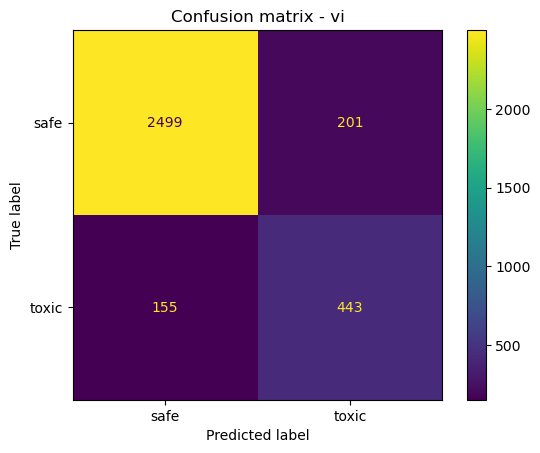


💾 Saved model: outputs_lang_aware/models/toxic_vi_language_aware_optimized.pkl
📄 Saved metadata: outputs_lang_aware/reports/toxic_vi_language_aware_optimized_metadata.json
📄 Saved threshold table: outputs_lang_aware/reports/toxic_vi_language_aware_optimized_threshold_table.csv
🔎 Saved FP: outputs_lang_aware/errors/toxic_vi_language_aware_optimized_false_positive.csv | rows: 201
🔎 Saved FN: outputs_lang_aware/errors/toxic_vi_language_aware_optimized_false_negative.csv | rows: 155


In [10]:
vi_result = None

if df_vi is not None:
    vi_result = train_language_model(
        df=df_vi,
        language="vi",
        model_name="toxic_vi_language_aware_optimized",
        lexicon=vi_lexicon,
        n_iter_search=N_ITER_SEARCH_VI,
        threshold_metric=THRESHOLD_METRIC_VI,
        min_precision_toxic=MIN_PRECISION_TOXIC_VI,
        min_recall_toxic=MIN_RECALL_TOXIC_VI,
    )
else:
    print("⚠️ Không có df_vi để train")

## 7. Train model tiếng Anh

Kỹ thuật đã áp dụng riêng cho tiếng Anh:

- Expand contractions: `can't -> can not`, `you're -> you are`, ...
- Normalize leetspeak nhẹ: `f0o`, `h4te` dạng token trộn chữ/số.
- Xử lý obfuscation: dấu `.`/`*`/`-` xen giữa ký tự.
- Word n-gram 1-3 và phrase n-gram 2-4.
- Char n-gram 3-6 để bắt biến thể né lọc.
- Optional lexicon từ `en_badwords.txt` nếu có.

In [ ]:
en_result = None

if df_en is not None:
    en_result = train_language_model(
        df=df_en,
        language="en",
        model_name="toxic_en_language_aware_optimized",
        lexicon=en_lexicon,
        n_iter_search=N_ITER_SEARCH_EN,
        threshold_metric=THRESHOLD_METRIC_EN,
        min_precision_toxic=MIN_PRECISION_TOXIC_EN,
        min_recall_toxic=MIN_RECALL_TOXIC_EN,
    )
else:
    print("⚠️ Không có df_en để train")

🚀 Train language=en | model=toxic_en_language_aware_optimized
Train/Valid/Test: 111169 23822 23823
Label ratio train:
label
0    0.904173
1    0.095827
Name: proportion, dtype: float64
Fitting 3 folds for each of 30 candidates, totalling 90 fits


## 8. Đánh giá trên test ngoài nếu có

Nếu bạn có `test_vi.csv` / `test_en.csv` độc lập, chạy cell này. Không dùng test ngoài để tune threshold.

In [ ]:
def evaluate_external_test(test_path: Path, language: str, model_path: Path):
    if not test_path.exists():
        print(f"⚠️ Không tìm thấy {test_path}, bỏ qua")
        return None
    if not model_path.exists():
        print(f"⚠️ Không tìm thấy model {model_path}, bỏ qua")
        return None

    df_test = read_dataset(
        test_path,
        language=language,
        text_candidates=["free_text", "comment_text", "text", "content"],
        label_candidates=["label_id", "label", "toxic", "target"],
        sample_n=None,
        random_state=RANDOM_STATE,
    )
    package = load_model_package(model_path)
    model = package["model"]
    threshold = float(package.get("threshold", 0.5))
    metrics = evaluate_binary(model, df_test["text"], df_test["label"], threshold=threshold)
    proba = get_positive_proba(model, df_test["text"])
    pred = (proba >= threshold).astype(int)

    print("=" * 90)
    print(f"📊 External test: {test_path} | language={language}")
    print(classification_report(df_test["label"], pred, target_names=["safe", "toxic"], zero_division=0))
    print("Metrics:", {k: v for k, v in metrics.items() if k not in ["classification_report", "confusion_matrix"]})
    print("Confusion matrix:", metrics["confusion_matrix"])

    out = df_test.copy()
    out["pred_label"] = pred
    out["prob_toxic"] = proba
    out["threshold"] = threshold
    out_path = REPORT_DIR / f"{model_path.stem}_{test_path.stem}_predictions.csv"
    out.to_csv(out_path, index=False, encoding="utf-8-sig")
    print("📄 Saved predictions:", out_path)
    return metrics

vi_external = evaluate_external_test(TEST_VI_PATH, "vi", MODEL_DIR / "toxic_vi_language_aware_optimized.pkl")
en_external = evaluate_external_test(TEST_EN_PATH, "en", MODEL_DIR / "toxic_en_language_aware_optimized.pkl")

## 9. Inference thử

Model nhận **raw text** trực tiếp. Không cần tự gọi `ViTokenizer`, không cần tự clean text ở backend.

In [ ]:
vi_model_path = MODEL_DIR / "toxic_vi_language_aware_optimized.pkl"
en_model_path = MODEL_DIR / "toxic_en_language_aware_optimized.pkl"

if vi_model_path.exists():
    vi_examples = [
        "Bạn làm tốt lắm, cảm ơn nhé",
        "đồ ngu biến đi",
        "dm m nói cái gì vậy",
        "khum thích cách bạn nói chuyện",
        "ban nay dot qua",
    ]
    print("🇻🇳 Vietnamese examples")
    display(predict_texts(vi_examples, vi_model_path))
else:
    print("⚠️ Chưa có model tiếng Việt")

if en_model_path.exists():
    en_examples = [
        "Thank you, that was helpful",
        "you are stupid, go away",
        "I can't believe this works",
        "you are such an idiot",
        "f*u*c*k off",
    ]
    print("🇬🇧 English examples")
    display(predict_texts(en_examples, en_model_path))
else:
    print("⚠️ Chưa có model tiếng Anh")

## 10. Cách deploy backend

Copy các file sau lên service Python/API:

- `outputs_lang_aware/models/toxic_vi_language_aware_optimized.pkl`
- `outputs_lang_aware/models/toxic_en_language_aware_optimized.pkl`
- `toxic_text_lang_utils.py`

Ví dụ:

In [ ]:
# from toxic_text_lang_utils import predict_texts
#
# vi_result = predict_texts(["đồ ngu"], "outputs_lang_aware/models/toxic_vi_language_aware_optimized.pkl")
# en_result = predict_texts(["you are stupid"], "outputs_lang_aware/models/toxic_en_language_aware_optimized.pkl")
# print(vi_result.to_dict(orient="records"))
# print(en_result.to_dict(orient="records"))

## 11. Optional — Fine-tune Transformer riêng cho VI/EN

Khi bạn có GPU, hướng tăng hiệu năng mạnh hơn TF-IDF là fine-tune Transformer:

- Tiếng Việt: `vinai/phobert-base-v2` hoặc XLM-R.
- Tiếng Anh: `roberta-base`, `distilbert-base-uncased`, hoặc model toxic pretrained nếu bạn có quyền tải.

Phần dưới để `RUN_TRANSFORMER = False` mặc định vì cần GPU và internet để tải pretrained model. TF-IDF vẫn là bản nhẹ, dễ deploy và thường đủ tốt cho moderation cơ bản.

In [ ]:
RUN_TRANSFORMER = False
TRANSFORMER_LANGUAGE = "vi"  # "vi" hoặc "en"

if RUN_TRANSFORMER:
    import evaluate
    import torch
    from datasets import Dataset
    from transformers import AutoModelForSequenceClassification, AutoTokenizer, DataCollatorWithPadding, Trainer, TrainingArguments

    source_df = df_vi if TRANSFORMER_LANGUAGE == "vi" else df_en
    if source_df is None:
        raise ValueError(f"Không có dữ liệu cho TRANSFORMER_LANGUAGE={TRANSFORMER_LANGUAGE}")

    checkpoint = "vinai/phobert-base-v2" if TRANSFORMER_LANGUAGE == "vi" else "distilbert-base-uncased"
    tokenizer = AutoTokenizer.from_pretrained(checkpoint, use_fast=(TRANSFORMER_LANGUAGE != "vi"))

    train_df, temp_df = train_test_split(source_df[["text", "label"]], test_size=0.30, stratify=source_df["label"], random_state=RANDOM_STATE)
    valid_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=RANDOM_STATE)

    def tok(batch):
        return tokenizer(batch["text"], truncation=True, max_length=160)

    train_ds = Dataset.from_pandas(train_df.reset_index(drop=True)).map(tok, batched=True)
    valid_ds = Dataset.from_pandas(valid_df.reset_index(drop=True)).map(tok, batched=True)
    test_ds = Dataset.from_pandas(test_df.reset_index(drop=True)).map(tok, batched=True)

    model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=2)
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
    f1_metric = evaluate.load("f1")

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        return {
            "f1_macro": f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"],
            "f1_toxic": f1_metric.compute(predictions=preds, references=labels, average="binary")["f1"],
        }

    args = TrainingArguments(
        output_dir=str(OUTPUT_DIR / f"transformer_{TRANSFORMER_LANGUAGE}"),
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=3,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        report_to="none",
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=valid_ds,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    trainer.train()
    print(trainer.evaluate(test_ds))

## 12. Checklist tối ưu sau khi chạy

Sau khi chạy xong, mở các file trong `outputs_lang_aware/errors/`:

- False Negative nhiều: model bỏ sót toxic → bổ sung dữ liệu toxic biến thể, giảm threshold, tăng char n-gram, thêm badword/teencode.
- False Positive nhiều: model gắn nhầm safe → thêm negative hard cases, tăng threshold, xem lại badword quá rộng.
- Nếu tiếng Việt không dấu sai nhiều: giữ nhánh `accentless_char` và bổ sung dữ liệu không dấu.
- Nếu tiếng Anh né lọc kiểu `f*u*c*k`, `1d10t` sai nhiều: tăng char n-gram và bổ sung dữ liệu obfuscation.

Đây là vòng lặp tối ưu quan trọng hơn việc chỉ đổi model.